# Fashion-MNIST Classification Project

This project builds a baseline neural network and three controlled experiments using TensorFlow/Keras.
The goal is to achieve at least 88% test accuracy without creating a large gap between training and validation performance.


## 1. Import Libraries


In [1]:
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization, Activation
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


## 2. Load the Dataset


In [2]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

print("Training images:", X_train_full.shape)
print("Training labels:", y_train_full.shape)
print("Test images:", X_test.shape)
print("Test labels:", y_test.shape)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


## 3. Data Preparation


In [3]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train_full
)

X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)
print("Pixel range:", X_train.min(), "to", X_train.max())


Training set: (48000, 28, 28)
Validation set: (12000, 28, 28)
Test set: (10000, 28, 28)
Pixel range: 0.0 to 1.0


The original test set is kept separate and is not used while comparing the experiments. Pixel values are divided by 255 so they are between 0 and 1.


## 4. Explore the Images


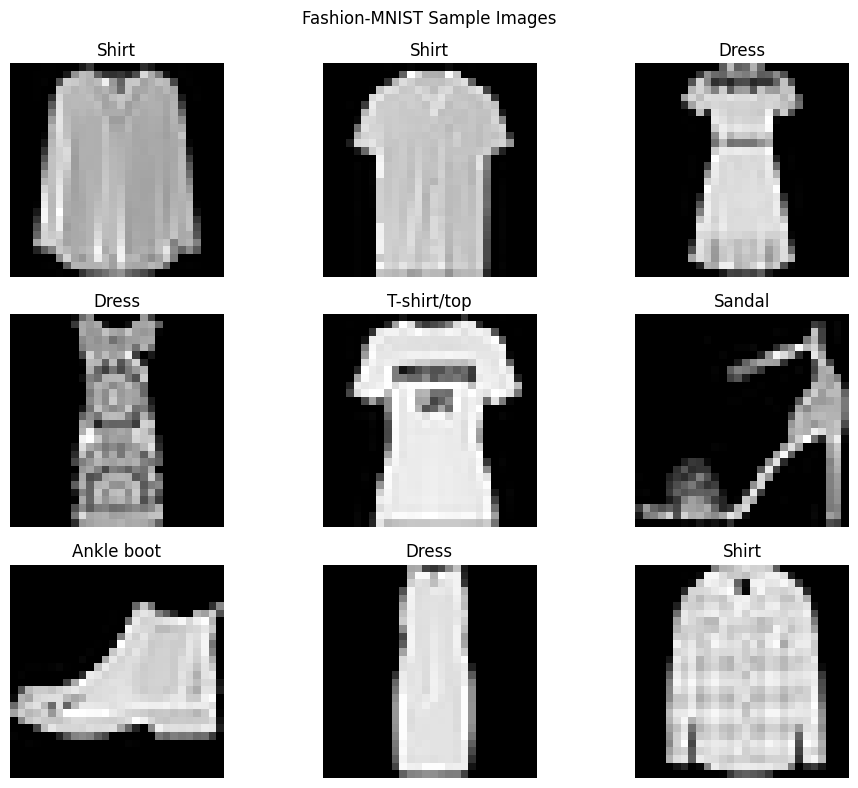

In [4]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

plt.figure(figsize=(10, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.suptitle("Fashion-MNIST Sample Images")
plt.tight_layout()
plt.show()


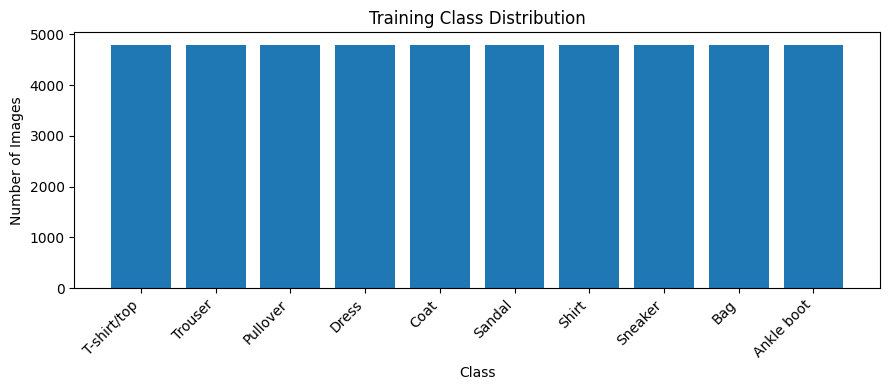

0    4800
1    4800
2    4800
3    4800
4    4800
5    4800
6    4800
7    4800
8    4800
9    4800
Name: count, dtype: int64


In [5]:
class_counts = pd.Series(y_train).value_counts().sort_index()

plt.figure(figsize=(9, 4))
plt.bar(class_names, class_counts.values)
plt.title("Training Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(class_counts)


The classes have almost the same number of images. Therefore, class weighting is not required.


## 5. Helper Functions


In [6]:
EPOCHS = 15
BATCH_SIZE = 128
results = {}

def compile_model(model, learning_rate=0.001):
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

def train_model(name, model):
    start_time = time.time()

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1
    )

    training_time = time.time() - start_time
    val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)

    results[name] = {
        "model": model,
        "history": history,
        "params": model.count_params(),
        "time": training_time,
        "train_accuracy": history.history["accuracy"][-1],
        "val_accuracy": val_accuracy,
        "val_loss": val_loss,
        "gap": history.history["accuracy"][-1] - val_accuracy
    }

    return history


In [7]:
def plot_history(history, title):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Training")
    plt.plot(history.history["val_accuracy"], label="Validation")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Training")
    plt.plot(history.history["val_loss"], label="Validation")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

def show_effect(previous_name, current_name):
    previous = results[previous_name]
    current = results[current_name]

    print("Effect of the modification")
    print(f"Parameters: {previous['params']:,} -> {current['params']:,}")
    print(f"Training time: {previous['time']:.1f}s -> {current['time']:.1f}s")
    print(f"Training accuracy: {previous['train_accuracy']:.4f} -> {current['train_accuracy']:.4f}")
    print(f"Validation accuracy: {previous['val_accuracy']:.4f} -> {current['val_accuracy']:.4f}")
    print(f"Validation loss: {previous['val_loss']:.4f} -> {current['val_loss']:.4f}")
    print(f"Train-validation gap: {previous['gap']:.4f} -> {current['gap']:.4f}")
    print("Test performance: not checked yet; the test set is reserved for the final model.")


## 6. Baseline Model


In [8]:
baseline_model = Sequential([
    keras.Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

compile_model(baseline_model)
baseline_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.7988 - loss: 0.5887 - val_accuracy: 0.8217 - val_loss: 0.4879
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8515 - loss: 0.4202 - val_accuracy: 0.8403 - val_loss: 0.4431
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8662 - loss: 0.3768 - val_accuracy: 0.8532 - val_loss: 0.4090
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8750 - loss: 0.3487 - val_accuracy: 0.8675 - val_loss: 0.3743
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8816 - loss: 0.3279 - val_accuracy: 0.8726 - val_loss: 0.3596
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8872 - loss: 0.3111 - val_accuracy: 0.8802 - val_loss: 0.3413
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8919 - loss: 0.2969 - val_accuracy: 0.8841 - val_loss: 0.3306
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8962 - loss: 0.2841 - val_accuracy: 

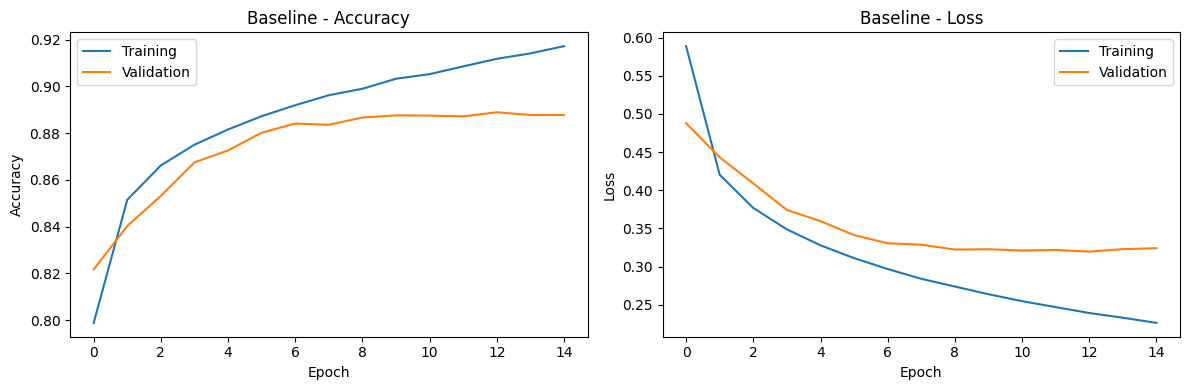

In [9]:
history_baseline = train_model("Baseline", baseline_model)
plot_history(history_baseline, "Baseline")


The baseline uses one hidden Dense layer with 128 units. ReLU is used in the hidden layer, and Softmax returns probabilities for the ten classes. Sparse categorical cross-entropy is suitable because the labels are stored as integers.


## 7. Experiment 1: Add One Hidden Layer


In [10]:
experiment1_model = Sequential([
    keras.Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

compile_model(experiment1_model)
experiment1_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7981 - loss: 0.5862 - val_accuracy: 0.8393 - val_loss: 0.4510
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8521 - loss: 0.4139 - val_accuracy: 0.8499 - val_loss: 0.4155
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8677 - loss: 0.3650 - val_accuracy: 0.8661 - val_loss: 0.3736
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8768 - loss: 0.3352 - val_accuracy: 0.8753 - val_loss: 0.3467
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8848 - loss: 0.3132 - val_accuracy: 0.8758 - val_loss: 0.3519
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8904 - loss: 0.2979 - val_accuracy: 0.8793 - val_loss: 0.3358
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8964 - loss: 0.2816 - val_accuracy: 0.8815 - val_loss: 0.3315
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9002 - loss: 0.2691 - val_accuracy: 0.

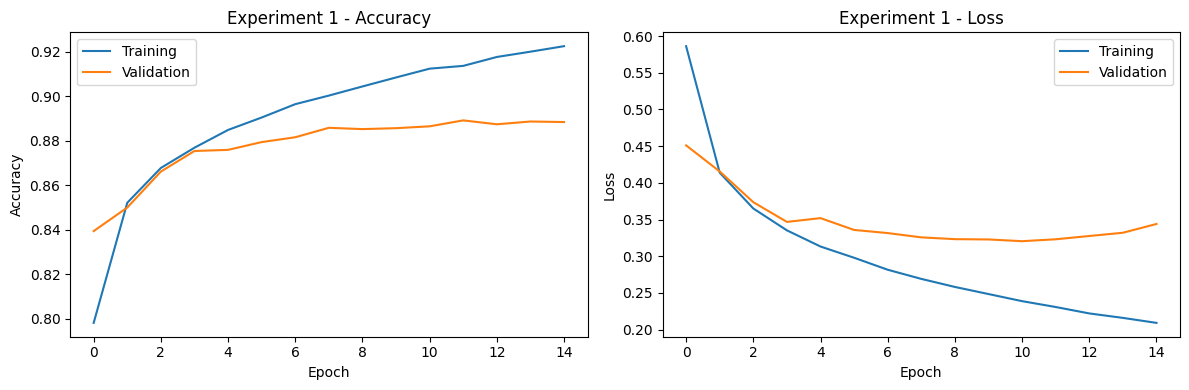

Effect of the modification
Parameters: 101,770 -> 109,386
Training time: 42.6s -> 42.3s
Training accuracy: 0.9172 -> 0.9224
Validation accuracy: 0.8878 -> 0.8883
Validation loss: 0.3241 -> 0.3439
Train-validation gap: 0.0294 -> 0.0341
Test performance: not checked yet; the test set is reserved for the final model.


In [11]:
history_exp1 = train_model("Experiment 1", experiment1_model)
plot_history(history_exp1, "Experiment 1")
show_effect("Baseline", "Experiment 1")


**Explanation:** This experiment changes only the network depth. The extra 64-unit layer increases the number of parameters and allows the model to learn more complex patterns. The printed results show whether this improves validation performance or only increases overfitting and training time.


## 8. Experiment 2: Add Batch Normalization and Dropout


In [12]:
experiment2_model = Sequential([
    keras.Input(shape=(28, 28)),
    Flatten(),
    Dense(128),
    BatchNormalization(),
    Activation("relu"),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(10, activation="softmax")
])

compile_model(experiment2_model)
experiment2_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,898 (429.29 KB)

 Trainable params: 109,642 (428.29 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7624 - loss: 0.6805 - val_accuracy: 0.8457 - val_loss: 0.4271
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8306 - loss: 0.4771 - val_accuracy: 0.8580 - val_loss: 0.3873
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8448 - loss: 0.4352 - val_accuracy: 0.8652 - val_loss: 0.3662
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8532 - loss: 0.4068 - val_accuracy: 0.8764 - val_loss: 0.3458
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8618 - loss: 0.3854 - val_accuracy: 0.8804 - val_loss: 0.3345
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8672 - loss: 0.3677 - val_accuracy: 0.8806 - val_loss: 0.3262
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8708 - loss: 0.3590 - val_accuracy: 0.8828 - val_loss: 0.3229
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8735 - loss: 0.3487 - val_accuracy: 0

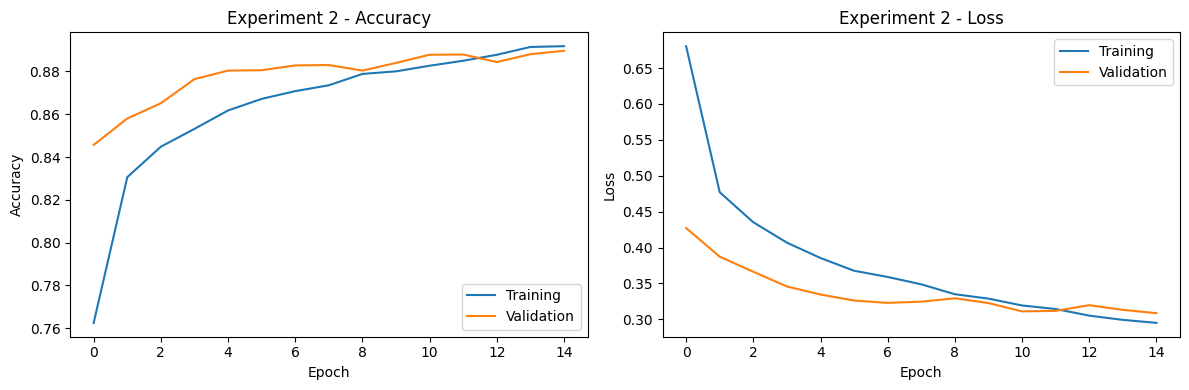

Effect of the modification
Parameters: 109,386 -> 109,898
Training time: 42.3s -> 44.5s
Training accuracy: 0.9224 -> 0.8918
Validation accuracy: 0.8883 -> 0.8897
Validation loss: 0.3439 -> 0.3086
Train-validation gap: 0.0341 -> 0.0022
Test performance: not checked yet; the test set is reserved for the final model.


In [13]:
history_exp2 = train_model("Experiment 2", experiment2_model)
plot_history(history_exp2, "Experiment 2")
show_effect("Experiment 1", "Experiment 2")


**Explanation:** Batch Normalization helps make training more stable, while Dropout randomly disables some neurons during training. Dropout does not add parameters, but it may reduce the train-validation gap and improve generalization.


## 9. Experiment 3: Lower the Learning Rate


In [14]:
experiment3_model = Sequential([
    keras.Input(shape=(28, 28)),
    Flatten(),
    Dense(128),
    BatchNormalization(),
    Activation("relu"),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(10, activation="softmax")
])

compile_model(experiment3_model, learning_rate=0.0005)
experiment3_model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,898 (429.29 KB)

 Trainable params: 109,642 (428.29 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7317 - loss: 0.7805 - val_accuracy: 0.8417 - val_loss: 0.4493
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8166 - loss: 0.5227 - val_accuracy: 0.8592 - val_loss: 0.3900
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8351 - loss: 0.4687 - val_accuracy: 0.8647 - val_loss: 0.3743
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8457 - loss: 0.4345 - val_accuracy: 0.8701 - val_loss: 0.3569
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8511 - loss: 0.4131 - val_accuracy: 0.8766 - val_loss: 0.3406
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8585 - loss: 0.3964 - val_accuracy: 0.8782 - val_loss: 0.3362
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8638 - loss: 0.3791 - val_accuracy: 0.8776 - val_loss: 0.3413
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8672 - loss: 0.3704 - val_accuracy: 0

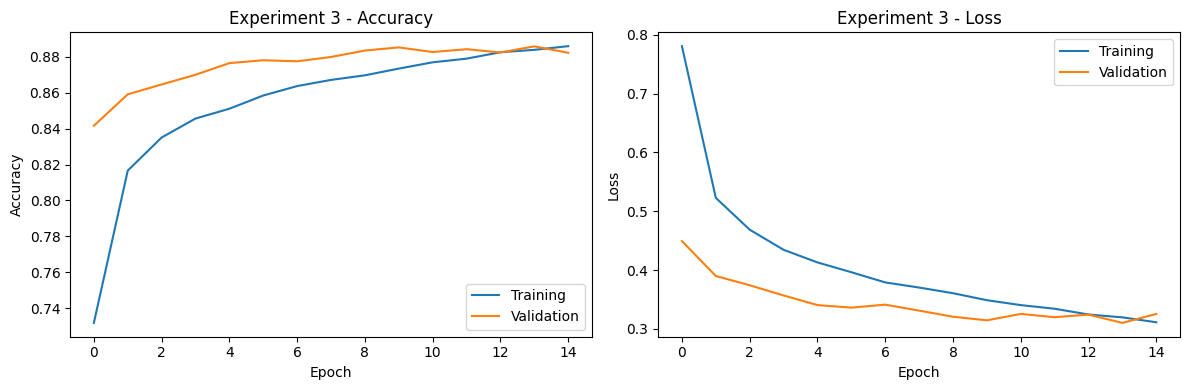

Effect of the modification
Parameters: 109,898 -> 109,898
Training time: 44.5s -> 45.6s
Training accuracy: 0.8918 -> 0.8860
Validation accuracy: 0.8897 -> 0.8823
Validation loss: 0.3086 -> 0.3255
Train-validation gap: 0.0022 -> 0.0037
Test performance: not checked yet; the test set is reserved for the final model.


In [15]:
history_exp3 = train_model("Experiment 3", experiment3_model)
plot_history(history_exp3, "Experiment 3")
show_effect("Experiment 2", "Experiment 3")


**Explanation:** This experiment keeps the architecture unchanged and lowers Adam's learning rate from 0.001 to 0.0005. The parameter count stays the same. A lower learning rate may improve convergence, although training can progress more slowly.


## 10. Experiment Comparison and Final Model


In [16]:
comparison_rows = []

for name, result in results.items():
    comparison_rows.append({
        "Model": name,
        "Parameters": result["params"],
        "Training Time (s)": round(result["time"], 1),
        "Training Accuracy": round(result["train_accuracy"], 4),
        "Validation Accuracy": round(result["val_accuracy"], 4),
        "Validation Loss": round(result["val_loss"], 4),
        "Train-Val Gap": round(result["gap"], 4)
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df


,Model,Parameters,Training Time (s),Training Accuracy,Validation Accuracy,Validation Loss,Train-Val Gap
0,Baseline,101770,42.6,0.9172,0.8878,0.3241,0.0294
1,Experiment 1,109386,42.3,0.9224,0.8883,0.3439,0.0341
2,Experiment 2,109898,44.5,0.8918,0.8897,0.3086,0.0022
3,Experiment 3,109898,45.6,0.8860,0.8823,0.3255,0.0037


In [17]:
best_name = comparison_df.sort_values(
    ["Validation Accuracy", "Validation Loss"],
    ascending=[False, True]
).iloc[0]["Model"]

final_model = results[best_name]["model"]
print("Selected final model:", best_name)
print("The selection is based only on validation results.")


Selected final model: Experiment 2
The selection is based only on validation results.


The final model is the experiment with the strongest validation accuracy. Validation loss, training time, parameter count, and the train-validation gap are also considered when the results are close.


## 11. Final Test Evaluation


In [18]:
y_prob = final_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred, average="macro")
test_recall = recall_score(y_test, y_pred, average="macro")
test_f1 = f1_score(y_test, y_pred, average="macro")

print(f"Test Accuracy:  {test_accuracy:.4f}")
print(f"Macro Precision: {test_precision:.4f}")
print(f"Macro Recall:    {test_recall:.4f}")
print(f"Macro F1-score:  {test_f1:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))


Test Accuracy:  0.8768
Macro Precision: 0.8770
Macro Recall:    0.8768
Macro F1-score:  0.8757

              precision    recall  f1-score   support

 T-shirt/top     0.8265    0.8290    0.8278      1000
     Trouser     0.9897    0.9640    0.9767      1000
    Pullover     0.7379    0.8530    0.7913      1000
       Dress     0.8441    0.9040    0.8730      1000
        Coat     0.8105    0.7740    0.7918      1000
      Sandal     0.9656    0.9550    0.9603      1000
       Shirt     0.7425    0.6170    0.6739      1000
     Sneaker     0.9256    0.9580    0.9415      1000
         Bag     0.9650    0.9660    0.9655      1000
  Ankle boot     0.9624    0.9480    0.9552      1000

    accuracy                         0.8768     10000
   macro avg     0.8770    0.8768    0.8757     10000
weighted avg     0.8770    0.8768    0.8757     10000



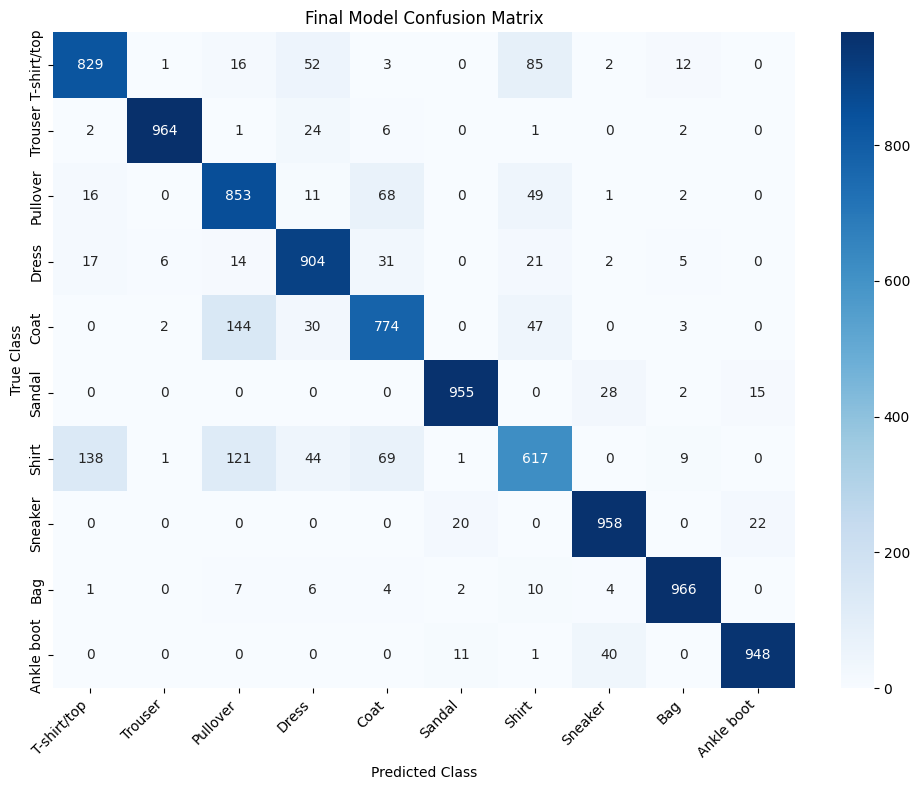

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Final Model Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 12. Analyze Five Incorrect Predictions


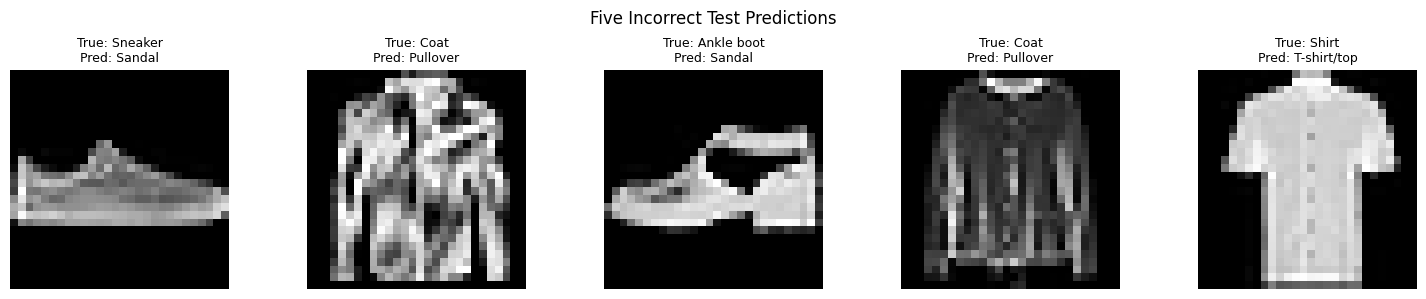

,True Class,Predicted Class,Confidence,Short Explanation
0,Sneaker,Sandal,0.5160,The footwear outline looks similar at low reso...
1,Coat,Pullover,0.4463,The two upper-body classes have a similar shape.
2,Ankle boot,Sandal,0.9721,The footwear outline looks similar at low reso...
3,Coat,Pullover,0.8209,The two upper-body classes have a similar shape.
4,Shirt,T-shirt/top,0.9345,The two upper-body classes have a similar shape.


In [20]:
wrong_indices = np.where(y_pred != y_test)[0][:5]
analysis = []

plt.figure(figsize=(15, 3))
for position, index in enumerate(wrong_indices):
    true_class = class_names[y_test[index]]
    predicted_class = class_names[y_pred[index]]
    confidence = y_prob[index][y_pred[index]]

    if true_class in ["T-shirt/top", "Shirt", "Pullover", "Coat"] and predicted_class in ["T-shirt/top", "Shirt", "Pullover", "Coat"]:
        reason = "The two upper-body classes have a similar shape."
    elif true_class in ["Sandal", "Sneaker", "Ankle boot"] and predicted_class in ["Sandal", "Sneaker", "Ankle boot"]:
        reason = "The footwear outline looks similar at low resolution."
    else:
        reason = "The image shape or shading is not very clear."

    analysis.append({
        "True Class": true_class,
        "Predicted Class": predicted_class,
        "Confidence": round(float(confidence), 4),
        "Short Explanation": reason
    })

    plt.subplot(1, 5, position + 1)
    plt.imshow(X_test[index], cmap="gray")
    plt.title(f"True: {true_class}\nPred: {predicted_class}", fontsize=9)
    plt.axis("off")

plt.suptitle("Five Incorrect Test Predictions")
plt.tight_layout()
plt.show()

pd.DataFrame(analysis)


## 13. Save the Model and Show Its Architecture


Model saved as best_model.keras


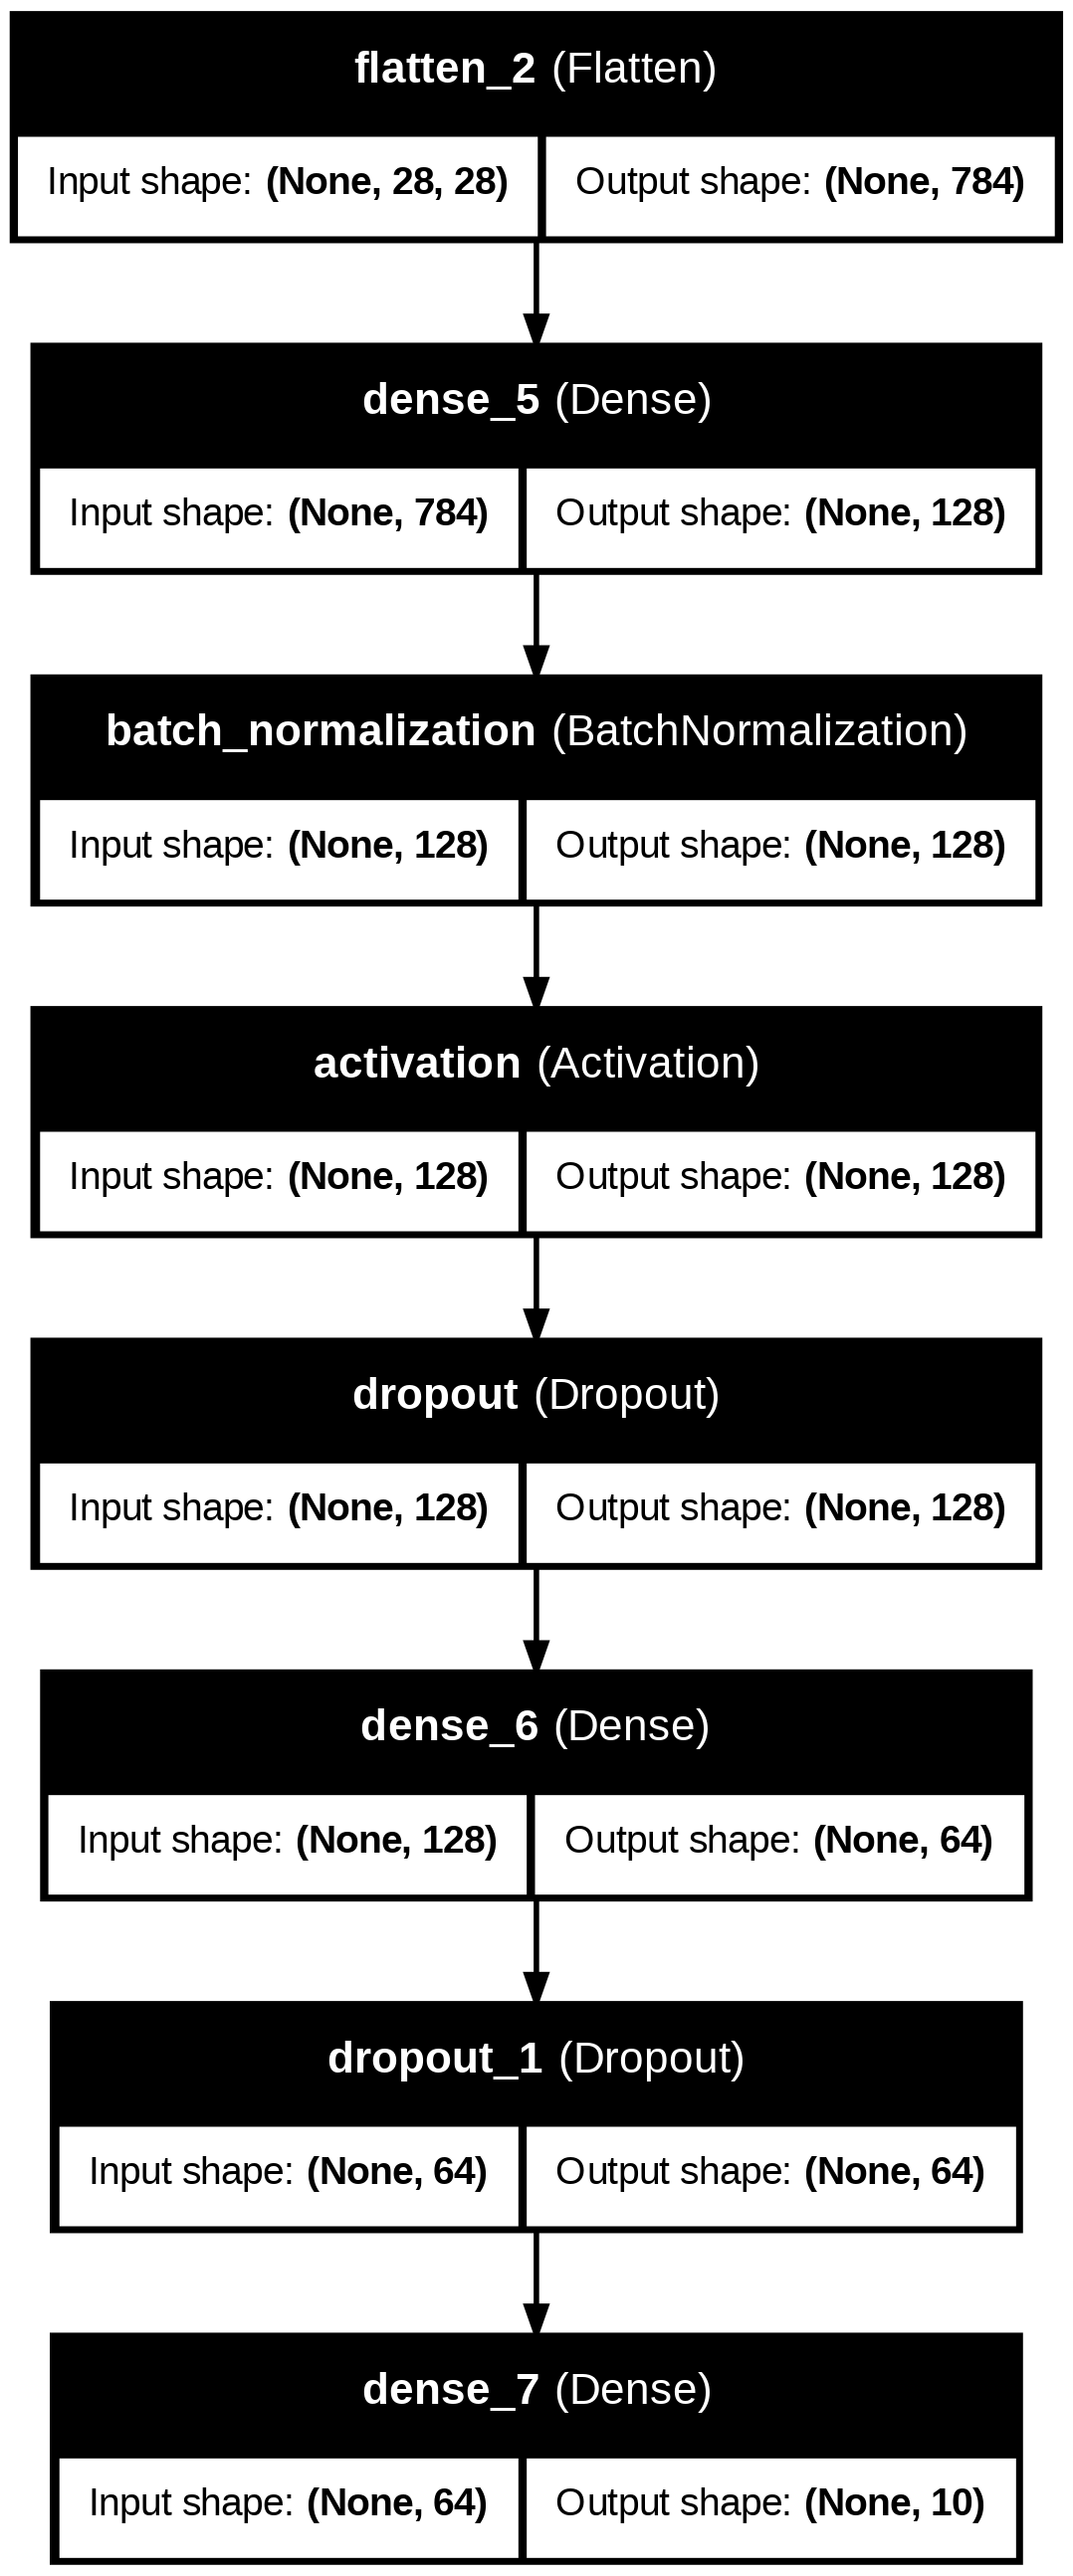

In [21]:
final_model.save("best_model.keras")
print("Model saved as best_model.keras")

keras.utils.plot_model(
    final_model,
    to_file="final_model_architecture.png",
    show_shapes=True,
    show_layer_names=True
)


## 14. Inference Function


In [22]:
def predict_image(image):
    image = np.asarray(image, dtype="float32")

    if image.shape != (28, 28):
        raise ValueError("The image must have shape (28, 28).")

    if image.max() > 1:
        image = image / 255.0

    probabilities = final_model.predict(image.reshape(1, 28, 28), verbose=0)[0]
    predicted_index = np.argmax(probabilities)

    return class_names[predicted_index], float(probabilities[predicted_index])

predicted_class, confidence = predict_image(X_test[0])
print("Predicted class:", predicted_class)
print(f"Confidence: {confidence:.2%}")


Predicted class: Ankle boot
Confidence: 95.02%


## 15. Conclusion

After running the notebook, answer these questions using the comparison table and confusion matrix:

1. **Why was the final architecture selected?**  
   It had the strongest validation performance while keeping the train-validation gap under control.

2. **How was it better than the baseline?**  
   Compare validation accuracy, validation loss, parameter count, training time, and the generalization gap in the table.

3. **Which classes were difficult?**  
   Use the largest off-diagonal values in the confusion matrix. Similar upper-body clothes are usually the most difficult at 28×28 resolution.

4. **Did the model overfit?**  
   Compare its final training and validation accuracies. A small gap suggests that overfitting was controlled.

5. **What could be tested next?**  
   A small CNN could be tested because it preserves the spatial structure of the images.
